In [4]:
import astropy.units as u
T_e = 5000 * u.K
n = 1e19 * u.m**-3
g_j = 2
g_k = 2
E_jk = 1 * u.Ry
T_e = 1 * u.Ry
n = 1e23 * u.m**-3


In [5]:
# from plasmapy.formulary.ionization import Saha
#don't trust plasmapy Saha, weird form
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
HIE = 13.598434 #elecron volt
SiIE = np.array([ 8.15168, 16.34585,33.49300,45.14179, 166.767,205.279,246.57,303.59,351.28,401.38,476.273,523.415       ])
labels=["Si I","Si II","Si III","Si IV","Si V","Si VI","Si VII","Si VIII","Si IX","Si X","Si XI","Si XII"]
T_e = np.arange(5000,70000,1000) * u.K
NA = 6.022e23
n  =1e6* NA*1e0/1.008* u.m**-3 #1gcc
print(n)
g_j = 2
g_k = 2
E_jk = HIE * u.eV
print(E_jk)
print(T_e)
Hratio = Saha(g_j, g_k, n, E_jk, T_e)
plt.plot(T_e,Hratio,label=r"$H^+/H$")
# for i in range(5):
#     E_jk = SiIE[i]*u.eV
#     plt.scatter(T_e[0], Saha(g_j, g_k, n, E_jk,15000*u.K),label=labels[i])
plt.title("Ionization fraction (1gcc)")
plt.ylabel("Ionization Fraction")
plt.grid()
plt.xlabel("Temperature (K)")
plt.yscale("log")
plt.legend()
plt.show()
gccarr = np.logspace(-9,0,100)
narr = 1e6* NA*gccarr/1.008* u.m**-3
T_e=15000
Hratio = Saha(g_j, g_k, narr, E_jk, T_e)
plt.plot(gccarr,Hratio,label=r"$H^+/H$")
plt.title("Ionization fraction (1gcc)")
plt.ylabel("Ionization Fraction")
plt.grid()
plt.xlabel("Temperature (K)")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.show()

5.9742063492063495e+29 1 / m3
13.598434 eV
[ 5000.  6000.  7000.  8000.  9000. 10000. 11000. 12000. 13000. 14000.
 15000. 16000. 17000. 18000. 19000. 20000. 21000. 22000. 23000. 24000.
 25000. 26000. 27000. 28000. 29000. 30000. 31000. 32000. 33000. 34000.
 35000. 36000. 37000. 38000. 39000. 40000. 41000. 42000. 43000. 44000.
 45000. 46000. 47000. 48000. 49000. 50000. 51000. 52000. 53000. 54000.
 55000. 56000. 57000. 58000. 59000. 60000. 61000. 62000. 63000. 64000.
 65000. 66000. 67000. 68000. 69000.] K


NameError: name 'Saha' is not defined

$$\frac{n_{i+1}n_e}{n_i}=\frac{(2\pi m kT)^{1.5}}{h^3}\frac{2g_{i+1}}{g_i}e^{-\chi/kT}$$
$$\frac{n_e^2}{n_T-n_e}=\frac{(2\pi m kT)^{1.5}}{h^3}\frac{2g_{i+1}}{g_i}e^{-\chi/kT}$$
$$n_e^2 +An_e - An_T= 0$$
$$n_e = \frac{-A}{2}+\frac{\sqrt{A^2+4An_T}}{2}$$

$$\frac{n_+}{n_T} = \frac{n_+}{n_0+n_+} = 1+\frac{n_+}{n_0}$$


In [9]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: C:\Users\shaoq\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


5.97420634920635e+24


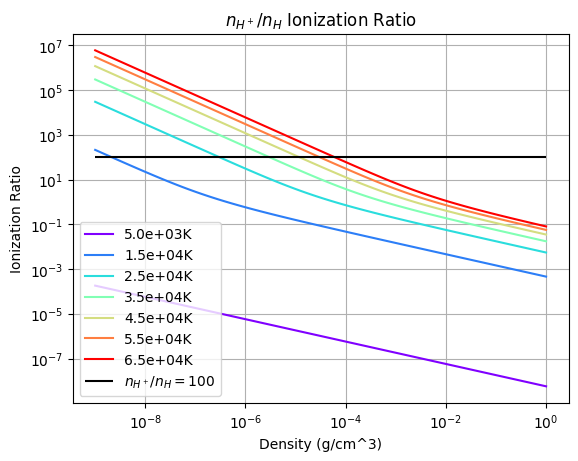

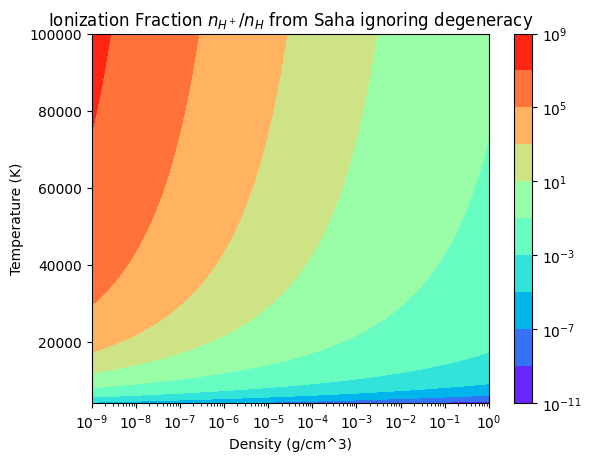

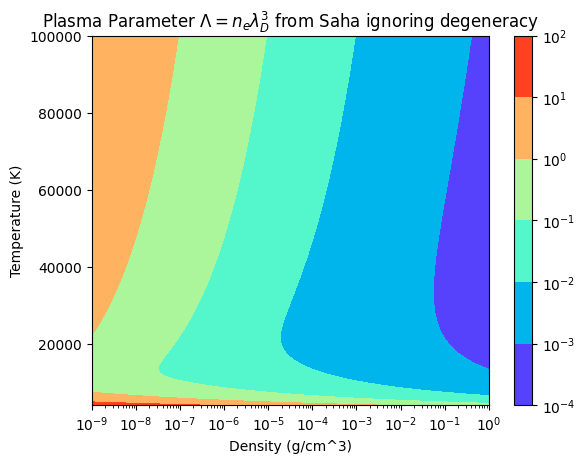

In [1]:
import math as math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker

NA = 6.022e23
nT =1e6* NA*1e-5/1.008
print(nT)
pi = 3.1415926535
qe = 1.6e-19
e = math.e
from matplotlib import cm
Tarr = np.arange(5000,10000*7,10000)
colors = cm.rainbow(np.linspace(0, 1, len(Tarr)))


    
#Ignore degeneracy
def SahaH(T,gcc): #total density in gcc
    nT = 1e6*NA*gcc/1.008
    chi = 13.54*1.6e-19 #hydrogen ionization energy
    h = 6.63e-34
    k = 1.38e-23
    m = 9.11e-31 #electron mass
    A = (np.power(2*pi*m*k*T,1.5))*np.exp(-chi/(k*T))/(h**3)
    ne = -0.5*A + 0.5*(np.sqrt(A**2+4*A*nT))
    return ne/(nT-ne),ne

def plasmaparameter(T,gcc):
    dump, nT = SahaH(T,gcc)
    k = 1.38e-23
    eps0 = 8.854e-12
    lD = (eps0*k*T/(4*pi*nT*(qe**2)))**0.5
    return lD,nT*(lD**3)

gccarr = np.logspace(-9,0,100)

for i in range(len(Tarr)):
    T = Tarr[i]
    result,ne = SahaH(T,gccarr)
    plt.plot(gccarr,result,color=colors[i],label="{:.1e}K".format(T))
plt.title(r"$n_{{H^+}}/n_H$ Ionization Ratio".format(T))
plt.hlines(100,xmin=np.min(gccarr),xmax=np.max(gccarr),color="black",label=r"$n_{H^+}/n_{H}=100$")
plt.ylabel("Ionization Ratio")
plt.yscale("log")
plt.grid()
plt.xlabel("Density (g/cm^3)")
plt.xscale("log")
plt.legend()
plt.show()


Tarr = np.linspace(4000,100000,1000)
gccarr = np.logspace(-9,0,1000)

data = np.zeros((len(Tarr),len(gccarr)))
ppdata = np.zeros((len(Tarr),len(gccarr)))

for i in range(len(Tarr)):
    dump,ppdata[i,:] = plasmaparameter(Tarr[i],gccarr)
    data[i,:],dump = SahaH(Tarr[i],gccarr)

fig, ax = plt.subplots()
cs = ax.contourf(gccarr, Tarr, data, locator=ticker.LogLocator(), cmap=cm.rainbow)
ax.set_xlabel("Density (g/cm^3)")
ax.set_ylabel("Temperature (K)")
ax.set_xscale("log")
ax.set_title(r"Ionization Fraction $n_{H^+}/n_{H}$ from Saha ignoring degeneracy")
cbar = fig.colorbar(cs)
plt.show()
fig, ax = plt.subplots()
cs = ax.contourf(gccarr, Tarr, ppdata, locator=ticker.LogLocator(), cmap=cm.rainbow)
ax.set_xlabel("Density (g/cm^3)")
ax.set_ylabel("Temperature (K)")
ax.set_xscale("log")
ax.set_title(r"Plasma Parameter $\Lambda = n_{e}\lambda_D^3$ from Saha ignoring degeneracy")
cbar = fig.colorbar(cs)
plt.show()

Plasma parameter
$$\Lambda = n_e\lambda_D^3$$
Debye Length
$$\lambda_D = \sqrt{\frac{\epsilon_0 k_BT}{4\pi e^2n_e}}$$

$$\frac{n_{i+1}n_e}{n_i}=\frac{(2\pi m kT)^{1.5}}{h^3}\frac{2g_{i+1}}{g_i}e^{-\chi/kT}$$
$$\frac{n_{i+1}}{n_i}=\frac{(2\pi m kT)^{1.5}}{n_eh^3}\frac{2g_{i+1}}{g_i}e^{-\chi/kT}$$


5.97420634920635e+24


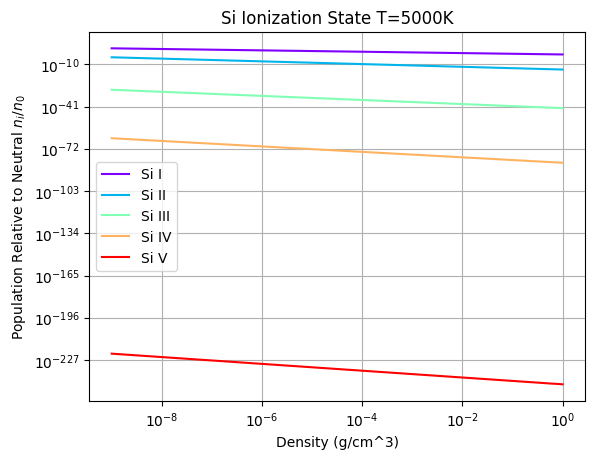

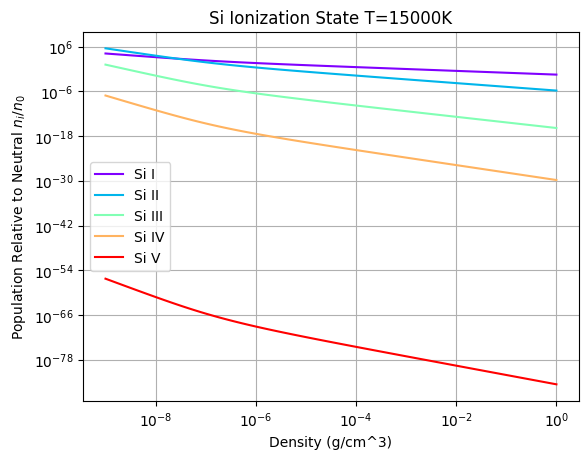

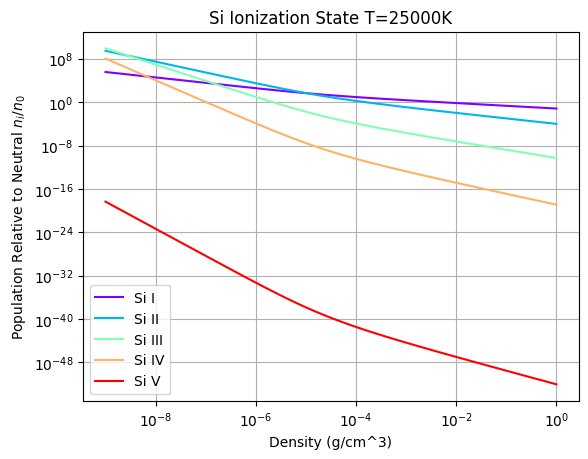

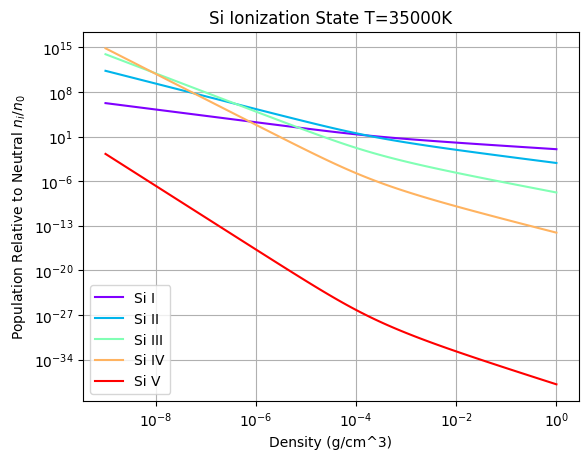

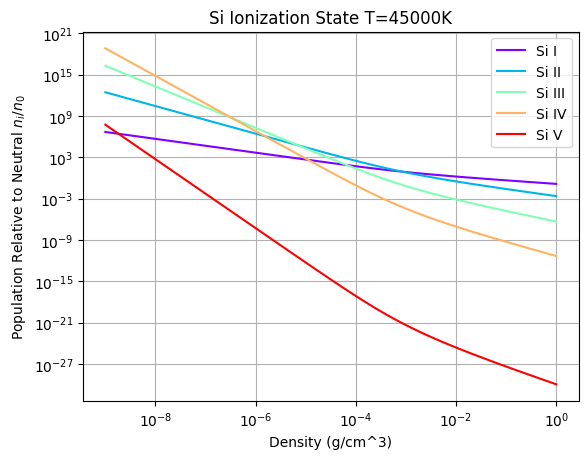

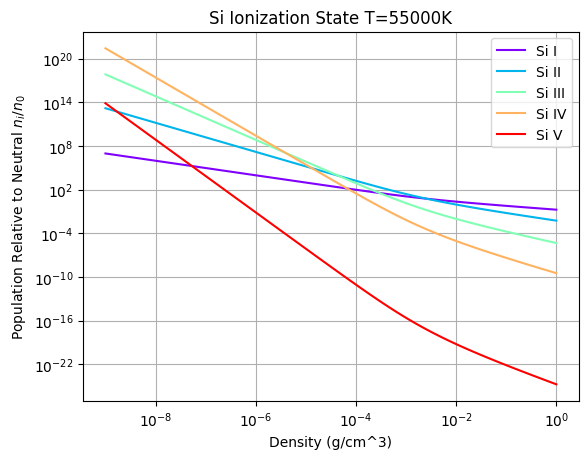

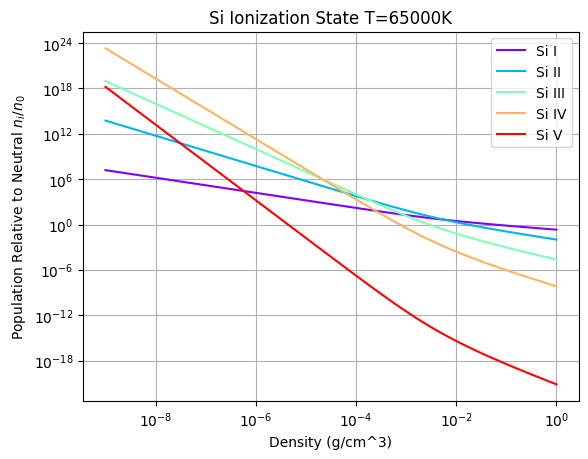

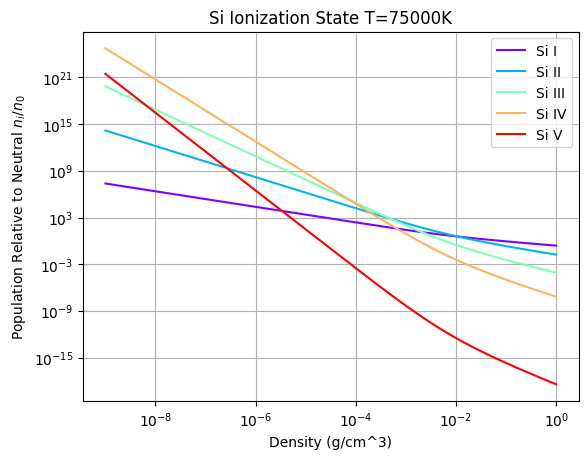

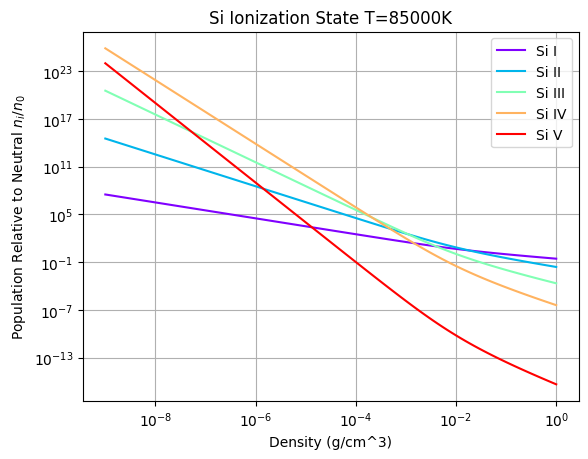

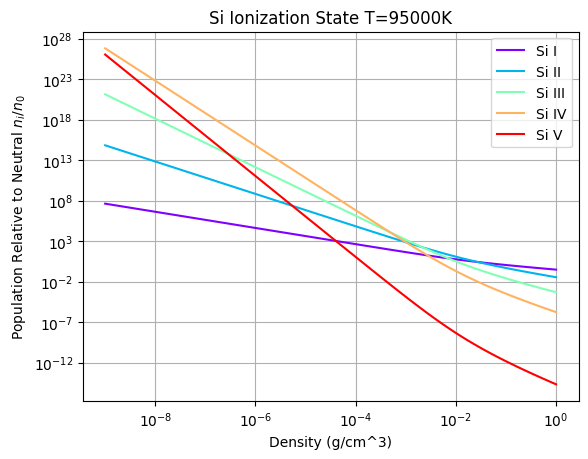

In [27]:
#Silicon
import math as math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker
from matplotlib import cm

NA = 6.022e23
nT =1e6* NA*1e-5/1.008
print(nT)
pi = 3.1415926535
qe = 1.6e-19
e = math.e
Tarr = np.arange(5000,10000*7,10000)

SiIE = np.array([ 8.15168, 16.34585,33.49300,45.14179, 166.767,205.279,246.57,303.59,351.28,401.38,476.273,523.415       ])
labels=["Si I","Si II","Si III","Si IV","Si V","Si VI","Si VII","Si VIII","Si IX","Si X","Si XI","Si XII"]
SiIE = SiIE[:5]
lables = labels[:5]
colors = cm.rainbow(np.linspace(0, 1, len(SiIE)))
    
#Ignore degeneracy
def SahaSi(T,gcc): #total density in gcc
    dump,ne = SahaH(T,gcc)
    h = 6.63e-34
    k = 1.38e-23
    m = 9.11e-31 #electron mass
    relpop = np.zeros((len(SiIE),len(gcc)))
    relpop[0,:] = ((2*pi*m*k*T)**1.5)*np.exp(-qe*SiIE[0]/(k*T))/(ne*h**3)
    for i in range(1,len(SiIE)):
        relpop[i,:] = relpop[i-1,:]*((2*pi*m*k*T)**1.5)*np.exp(-qe*SiIE[i]/(k*T))/(ne*h**3)
    return relpop
Tarr = np.arange(5000,100000,10000)
for i in range(len(Tarr)):
    T = Tarr[i]
    gccarr = np.logspace(-9,0,100)
    data = SahaSi(T,gccarr)
    for i in range(len(SiIE)):
        plt.plot(gccarr,data[i,:],color=colors[i],label=labels[i])
    plt.title("Si Ionization State T={}K".format(T))
    plt.ylabel(r"Population Relative to Neutral $n_i/n_0$")
    plt.yscale("log")
    plt.grid()
    plt.xlabel("Density (g/cm^3)")
    plt.xscale("log")
    plt.legend()
    plt.show()




# Coupling Parameter

0.0004876794319541023


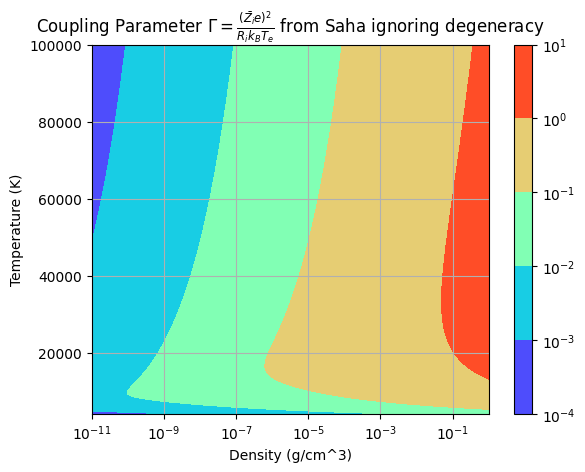

In [ ]:
import math as math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker

NA = 6.022e23
nT =1e6* NA*1e-5/1.008
pi = 3.1415926535
qe = 1.6e-19
e = math.e
from matplotlib import cm
Tarr = np.arange(5000,10000*7,10000)
colors = cm.rainbow(np.linspace(0, 1, len(Tarr)))


    
#Ignore degeneracy
def SahaH(T,gcc): #total density in gcc
    nT = 1e6*NA*gcc/1.008
    chi = 13.54*1.6e-19 #hydrogen ionization energy
    h = 6.63e-34
    k = 1.38e-23
    m = 9.11e-31 #electron mass
    A = (np.power(2*pi*m*k*T,1.5))*np.exp(-chi/(k*T))/(h**3)
    ne = -0.5*A + 0.5*(np.sqrt(A**2+4*A*nT))
    return ne/(nT-ne),ne

def plasmaparameter(T,gcc):
    dump, nT = SahaH(T,gcc)
    k = 1.38e-23
    eps0 = 8.854e-12
    lD = (eps0*k*T/(4*pi*nT*(qe**2)))**0.5
    return lD,nT*(lD**3)

def couplingparameter(T,gcc):
    dump, ne =  SahaH(T,gcc)
    k = 1.38e-23
    eps0 = 8.854e-12
    R = np.power((0.75/(pi*ne)),(1/3))
    avgq = qe #hydrogen dominates average charge
    return (avgq**2)/(4*pi*eps0*R*k*T)






Tarr = np.linspace(4000,100000,1000)
gccarr = np.logspace(-11,0,1000)

ppdata = np.zeros((len(Tarr),len(gccarr)))

for i in range(len(Tarr)):
    ppdata[i,:] = couplingparameter(Tarr[i],gccarr)
print(np.min(ppdata[i,:]))
fig, ax = plt.subplots()
cs = ax.contourf(gccarr, Tarr, ppdata, locator=ticker.LogLocator(), cmap=cm.rainbow)
ax.set_xlabel("Density (g/cm^3)")
ax.set_ylabel("Temperature (K)")
ax.set_xscale("log")
ax.grid()
ax.set_title(r"Coupling Parameter $\Gamma = \frac{(\bar{Z_i}e)^2}{4\pi\epsilon_0R_ik_BT_e} $ from Saha ignoring degeneracy")
cbar = fig.colorbar(cs)
plt.show()
